### Google에서 "LG전자 신혼"으로 검색한 후, 최근 1년 이내 뉴스 기사들의 제목 데이터 수집
- 워드클라우드 분석

In [1]:
# 라이브러리 불러오기
from selenium import webdriver as wb # web browser
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
import time
import pandas as pd
import re
from tqdm import tqdm

# 문자열 전처리 함수 -> 숫자, 문자, 특수문자 제외하고 삭제
def preprocess_sentence_kr(w):
  w = w.strip()
  w = re.sub(r"[^0-9가-힣?.!,¿]+", " ", w) 
  w = w.strip() 
  return w

In [2]:
driver = wb.Chrome()
driver.get('https://www.google.com/') 

In [3]:
s = driver.find_element(By.CSS_SELECTOR, 'textarea.gLFyf')
# s.send_keys('LG전자 신혼'+'\n') # \n 브라우저 입장에서는 Enter 키로 인식
s.send_keys('LG전자 신혼'+'\n') # \n 브라우저 입장에서는 Enter 키로 인식

In [5]:
# 뉴스 탭 클릭
news_click = driver.find_element(By.CSS_SELECTOR, '#_SPAKafv0Mf-m2roPtLTioAw_53 > div.HTOhZ > div > div > div.beZ0tf.O1uzAe > div:nth-child(6) > a > div')
news_click.click()

In [6]:
# '도구' 클릭
option_btn = driver.find_element(By.ID, 'hdtb-tls')
option_btn.click()
time.sleep(1)

In [8]:
# '최근 항목' -> '지난 1년' 클릭
newest_btn = driver.find_element(By.CSS_SELECTOR, '#ow16 > div.UsmT1.Esm33e > div')
newest_btn.click()
time.sleep(1)

newest_1y_btn = driver.find_element(By.CSS_SELECTOR, '#_bPAKaZu0Jfrc2roPuIPbgAU_24 > div:nth-child(8) > div > a')
newest_1y_btn.click()
time.sleep(1)

In [12]:
# 페이지 마다 모든 뉴스기사 제목 크롤링
page_N = 1000 # 임의의 큰 값
title_list = []

f = open('./data/google_LG전자+신혼_뉴스 타이틀.txt', 'w', encoding='utf-8')
for p in tqdm(range(page_N)):
    print(f'{p+1} 페이지')
    try:
        # 뉴스 타이틀 정보 가져오기
        titles = driver.find_elements(By.CSS_SELECTOR, 'div.n0jPhd.ynAwRc.MBeuO.nDgy9d')
        print(f'뉴스 기사 {len(titles)} 개')
        for title in titles:
            title_list.append(title.text)
            f.write(title.text)
        
        # 다음 페이지 넘어가기
        nextBtn = driver.find_element(By.CSS_SELECTOR, '#pnnext > span.SJajHc.NVbCr') # d6cvqb BBwThe
        nextBtn.click()
        time.sleep(1)
    except:
        print("Done")
        break
    
f.close()



  0%|          | 0/1000 [00:00<?, ?it/s]

1 페이지
뉴스 기사 10 개


  0%|          | 1/1000 [00:02<35:00,  2.10s/it]

2 페이지
뉴스 기사 10 개


  0%|          | 2/1000 [00:04<36:09,  2.17s/it]

...

5 페이지
뉴스 기사 10 개


  0%|          | 5/1000 [00:11<38:00,  2.29s/it]

6 페이지
뉴스 기사 10 개


  1%|          | 6/1000 [00:13<37:17,  2.25s/it]

7 페이지
뉴스 기사 0 개
Done


In [10]:
title_list[-1]

'LH, 신혼·신생아·다자녀 전세임대 입주자 모집…HDC현대산업개발, 아이파크 입주민 대상 찾아가는 서비스 확대 [건설오늘]'

In [13]:
f = open('./data/google_LG전자+신혼_뉴스 타이틀.txt', 'r', encoding='utf-8')
new_titles = f.readline()
f.close()

In [14]:
# 라이브러리 불러오기
from kiwipiepy import Kiwi # 형태소 분석기
from collections import Counter # 단어가 나온 횟수를 셈
from wordcloud import WordCloud # 워드클라우드 생성 도구
import matplotlib.pyplot as plt # 시각화 도구
from PIL import Image
import numpy as np

In [16]:
# 도구 객체생성
kiwi = Kiwi()

# 토큰화
token = kiwi.tokenize(new_titles)
token

# form: 토큰화 결과
# tag: 품사 태크
# nnp: 고유명사; nng: 일반명사

[Token(form='LG전자', tag='NNP', start=0, len=4),
 Token(form='베스트', tag='NNG', start=5, len=3),
 Token(form='샵', tag='NNG', start=8, len=1),
 Token(form=',', tag='SP', start=9, len=1),
 Token(form='신혼부부', tag='NNG', start=11, len=4),
 Token(form='대상', tag='NNG', start=16, len=2),
 Token(form='가전', tag='NNG', start=19, len=2),
 Token(form='프로모션', tag='NNG', start=22, len=4),
 Token(form='“', tag='SSO', start=26, len=1),
 Token(form='자기', tag='NNG', start=27, len=2),
 Token(form='야', tag='JKV', start=29, len=1),
 Token(form='우리', tag='NP', start=31, len=2),
 Token(form='TV', tag='SL', start=34, len=2),
 Token(form='뭐', tag='IC', start=37, len=1),
 Token(form='살', tag='VV', start=38, len=1),
 Token(form='ᆯ까', tag='EF', start=38, len=2),
 Token(form='?', tag='SF', start=40, len=1),
 Token(form='”', tag='SSC', start=41, len=1),
 Token(form='…', tag='SE', start=42, len=1),
 Token(form='신혼부부', tag='NNG', start=43, len=4),
 Token(form='들', tag='XSN', start=47, len=1),
 Token(form='이', tag='JKS'

In [17]:
# 일반명사만 추출 (NNG)
# 리스트명 = [실행문 반복문 조건]
# nng_token = [t.form for t in token if t.tag=='NNG']
nng_token = [t.form for t in token if t.tag=='NNG' or t.tag=='NNP']

print(len(nng_token))
print(nng_token)

484
['LG전자', '베스트', '샵', '신혼부부', '대상', '가전', '프로모션', '자기', '신혼부부', 'LG전자', '홈페이지', '사연', '신혼부부', '싱크대', '밑', '야심작', '전자', '베스트', '샵', '신혼부부', '가전', '구매', '혜택', '확대', '전자', '베스트', '샵', '대전', '본점', '그랜드', '오픈', '신혼', '혼수', '가전', '가전', '구독', '행사', '진행', '신혼', '가전', '대금', '잠적', '전자', '판매점', '지점장', '고소', '전자', '베스트', '샵', '신혼부부', '맞춤', '가전', '혜택', '강화', '이벤트', '다각', '신혼부부', 'LG전자', '베스트', '샵', '판매점', '매니저', '구매', '대금', '먹튀', '전자', '베스트', '샵', '대전', '본점', '그랜드', '오픈', '결혼', '혼수', '가전', '가전', '구독', '특별', '혜택', '제공', '신혼부부', '웨딩', '페어', '혜택', '전자', '공식', '대리점', '서', '고객', '돈', '먹튀', '피해자', '제품', '값', '잠적', '예비', '신혼', '부부', '피해', 'LG전자', '선제', '보상', '전자', '전문점', '지점장', '예비', '신혼부부', '결제', '금', '잠적', '경찰', '수사', '착수', '전자', '베스트', '샵', '롯데', '본점', '리뉴얼', '오픈', '기념', '가전제품', '세일', '행사', '모니터', '사이', '삼성', '이동', '가전', '흥행', 'LG전자', '베스트', '샵', '신혼부부', '웨딩', '시즌', '프로모션', '진행', '신혼부부', '가전제품', '대박', '박', '삼성', '신혼부부', '가전', '전자', '베스트', '샵', '수원', '연합', '가전', '그랜드', '세일', '진행', '전자', '베스트', '샵', '

In [18]:
# 2글자 이상의 단어만 추출
nng_token2 = [t for t in nng_token if len(t)>=2]
nng_token2

['LG전자',
 '베스트',
 '신혼부부',
 '대상',
 '가전',
 '프로모션',
 '자기',
 '신혼부부',
 'LG전자',
 '홈페이지',
 '사연',
 '신혼부부',
 '싱크대',
 '야심작',
 '전자',
 '베스트',
 '신혼부부',
 '가전',
 '구매',
 '혜택',
 '확대',
 '전자',
 '베스트',
 '대전',
 '본점',
 '그랜드',
 '오픈',
 '신혼',
 '혼수',
 '가전',
 '가전',
 '구독',
 '행사',
 '진행',
 '신혼',
 '가전',
 '대금',
 '잠적',
 '전자',
 '판매점',
 '지점장',
 '고소',
 '전자',
 '베스트',
 '신혼부부',
 '맞춤',
 '가전',
 '혜택',
 '강화',
 '이벤트',
 '다각',
 '신혼부부',
 'LG전자',
 '베스트',
 '판매점',
 '매니저',
 '구매',
 '대금',
 '먹튀',
 '전자',
 '베스트',
 '대전',
 '본점',
 '그랜드',
 '오픈',
 '결혼',
 '혼수',
 '가전',
 '가전',
 '구독',
 '특별',
 '혜택',
 '제공',
 '신혼부부',
 '웨딩',
 '페어',
 '혜택',
 '전자',
 '공식',
 '대리점',
 '고객',
 '먹튀',
 '피해자',
 '제품',
 '잠적',
 '예비',
 '신혼',
 '부부',
 '피해',
 'LG전자',
 '선제',
 '보상',
 '전자',
 '전문점',
 '지점장',
 '예비',
 '신혼부부',
 '결제',
 '잠적',
 '경찰',
 '수사',
 '착수',
 '전자',
 '베스트',
 '롯데',
 '본점',
 '리뉴얼',
 '오픈',
 '기념',
 '가전제품',
 '세일',
 '행사',
 '모니터',
 '사이',
 '삼성',
 '이동',
 '가전',
 '흥행',
 'LG전자',
 '베스트',
 '신혼부부',
 '웨딩',
 '시즌',
 '프로모션',
 '진행',
 '신혼부부',
 '가전제품',
 '대박',
 '삼성',
 '신혼부부',
 '가전',
 '전자',
 '베스트',
 '수

In [19]:
# 명사의 개수를 세서 많이 나오는 단어를 활용하여 워드클라욷 생성하기
counter = Counter(nng_token2)
counter

Counter({'가전': 21,
         '신혼부부': 20,
         '전자': 18,
         '베스트': 16,
         '웨딩': 12,
         '신혼': 8,
         'LG전자': 7,
         '혜택': 7,
         '오픈': 7,
         '페어': 7,
         '예비': 7,
         '진행': 6,
         '대상': 5,
         '프로모션': 5,
         '혼수': 5,
         '잠적': 5,
         '지점장': 5,
         '롯데백화점': 5,
         '본점': 4,
         '그랜드': 4,
         '행사': 4,
         '제품': 4,
         '부부': 4,
         '롯데': 4,
         '기념': 4,
         '개최': 4,
         '명품': 4,
         '구매': 3,
         '결혼': 3,
         '피해': 3,
         '리뉴얼': 3,
         '삼성': 3,
         '백화점': 3,
         '스타': 3,
         '요금': 3,
         '단독': 3,
         '이상': 3,
         '지원': 3,
         '확대': 2,
         '대전': 2,
         '구독': 2,
         '대금': 2,
         '판매점': 2,
         '맞춤': 2,
         '먹튀': 2,
         '특별': 2,
         '제공': 2,
         '대리점': 2,
         '가전제품': 2,
         '세일': 2,
         '출시': 2,
         '이름': 2,
         '사기': 2,
         '역대': 2,
     

In [24]:
# 상위 N개 단어만 추출
top_N = counter.most_common(50)
top_N

[('가전', 21),
 ('신혼부부', 20),
 ('전자', 18),
 ('베스트', 16),
 ('웨딩', 12),
 ('신혼', 8),
 ('LG전자', 7),
 ('혜택', 7),
 ('오픈', 7),
 ('페어', 7),
 ('예비', 7),
 ('진행', 6),
 ('대상', 5),
 ('프로모션', 5),
 ('혼수', 5),
 ('잠적', 5),
 ('지점장', 5),
 ('롯데백화점', 5),
 ('본점', 4),
 ('그랜드', 4),
 ('행사', 4),
 ('제품', 4),
 ('부부', 4),
 ('롯데', 4),
 ('기념', 4),
 ('개최', 4),
 ('명품', 4),
 ('구매', 3),
 ('결혼', 3),
 ('피해', 3),
 ('리뉴얼', 3),
 ('삼성', 3),
 ('백화점', 3),
 ('스타', 3),
 ('요금', 3),
 ('단독', 3),
 ('이상', 3),
 ('지원', 3),
 ('확대', 2),
 ('대전', 2),
 ('구독', 2),
 ('대금', 2),
 ('판매점', 2),
 ('맞춤', 2),
 ('먹튀', 2),
 ('특별', 2),
 ('제공', 2),
 ('대리점', 2),
 ('가전제품', 2),
 ('세일', 2)]

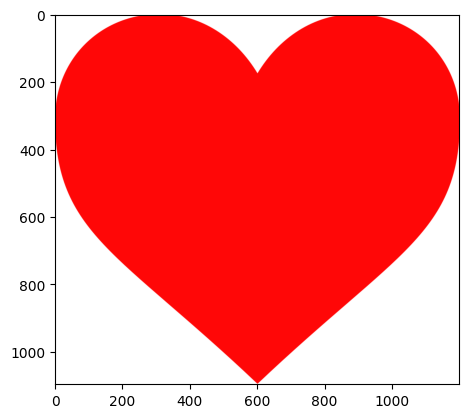

In [25]:
icon = Image.open('./data/heart.png')    # 마스크가 될 이미지 불러오기 
# plt.imshow(icon)

mask = Image.new("RGB", icon.size, (255,255,255))

mask.paste(icon,icon)
mask = np.array(mask)
plt.imshow(mask)

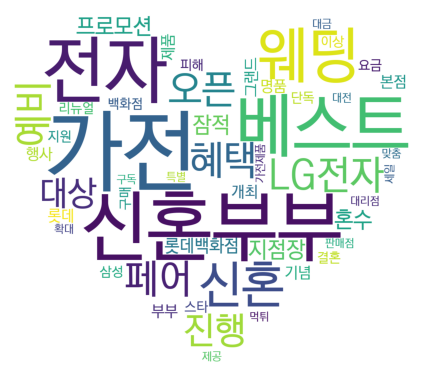

In [26]:
# WordCloud(): 스타일(배경,글꼴), 최대단어수, 마스크이미지 등 옵션을 설정
# generate_from_frequencies(): 미리 정의된 단어의 빈도수를 이용해서 워드클라우드 이미지를 생성

wc = WordCloud(
    font_path='C:/Windows/Fonts/LG PC.ttf', # malgunbd.ttf
    background_color='white',
    mask=mask
        
).generate_from_frequencies(dict(top_N))

plt.imshow(wc)
plt.axis('off')
plt.show()